<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
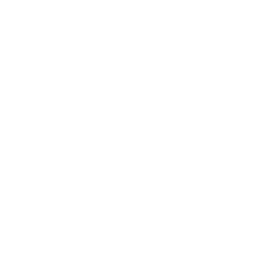
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Osaruutukoeasetelma prosessin optimointiin</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Valmistus / Laadunhallinta &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Tämä muistikirja analysoi osaruutukoeasetelman ruiskuvaluprosessille.
Pääruututekijä on **kone** (4 tasoa: MACH_A-MACH_D), jota on vaikea
vaihtaa, ja osaruututekijä on **nopeusasetus** (5 tasoa: 60, 80, 100,
120, 140 RPM), jota on helppo vaihtaa. Jokaisessa kone x nopeus
-yhdistelmässä tehdään viisi rinnakkaismittausta, mikä antaa 100
vikaprosenttihavaintoa.

`PROC MIXED` sovittaa rajoitetun satunnaistuksen rakenteen oikein
käsittelemällä **konetta satunnaisvaikutuksena** (pääruudun
virhekerros) ja **nopeutta kiinteänä vaikutuksena** (osaruututekijä).
Analyysi estimoi kaksi varianssikomponenttia, testaa nopeusvaikutuksen
ja tuottaa Tukey-korjatut parivertailut nopeuden PNS-keskiarvoille,
jotta voidaan tunnistaa käyttönopeus, joka minimoi vikaprosentin.

## Datalähteet

| Lähde | Kuvaus | Tietueet |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Osaruutukokeen data: 4 konetta x 5 nopeutta x 5 rinnakkaismittausta | 100 |

---

In [1]:
/* --------------------------------------------------------
   Luodaan synteettinen osaruutukoeaineisto ruiskuvalulle
   4 konetta (pääruutu) x 5 nopeutta (osaruutu) x 5 rinnakkaismittausta
   Lisärinnakkaismittaukset jokaiselle pääruudulle
   -------------------------------------------------------- */
TIEDOT work.molding_experiment;
    CALL streaminit(42);
    TAULUKKO machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    TAULUKKO speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Todelliset konevaikutukset (satunnaiset) */
    TAULUKKO mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Todelliset nopeusvaikutukset (kiinteät, kvadraattiset, optimi noin 100) */
    TAULUKKO speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    TEE whole_plot = 1 ASTI 5;
        TEE m = 1 ASTI 4;
            machine = machine_names[m];
            machine_id = cat('WP_', KIRJOITA(whole_plot, z2.), '_', machine);
            /* Pääruudun rinnakkaismittausvaikutus */
            wp_noise = rand('normal', 0, 1.5);
            TEE s = 1 ASTI 5;
                speed = speed_settings[s];
                speed_label = cat(KIRJOITA(speed, 3.), 'RPM');
                /* Osaruudun rinnakkaismittaukset kunkin pääruudun sisällä */
                TEE rep = 1 ASTI 5;
                    obs_id + 1;
                    /* Vikaprosentti: vakiotermi + kone + nopeus + yhdysvaikutus + kohina */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    JOS defect_rate < 0 NIIN defect_rate = 0.01;
                    /* Toissijainen vaste: vetolujuus */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    TULOSTE;
                LOPPU;
            LOPPU;
        LOPPU;
    LOPPU;
    POISTA m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
SUORITA;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Lähtötilanne: vikaprosentin yhteenveto koneen ja nopeuden mukaan
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.molding_experiment n mean std;
    LUOKKA machine speed_label;
    MUUTTUJA defect_rate tensile_strength;
    NIMIKE machine='Kone' speed_label='Nopeusasetus'
          defect_rate='Vikaprosentti (%)' tensile_strength='Vetolujuus';
    OTSIKKO 'Vikaprosentti ja vetolujuus koneen ja nopeuden mukaan';
SUORITA;

                                 Vikaprosentti ja vetolujuus koneen ja nopeuden mukaan                                  

                                                  The MEANS Procedure

                                   Analysis Variable : defect_rate Vikaprosentti (%)

        Kone      Nopeusasetus          N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        MACH_A     60RPM                    5     12.9460000      1.0100149
        MACH_A     80RPM                    5     10.0160000      0.6740401
        MACH_A    100RPM                    5      7.5980000      0.9787083
        MACH_A    120RPM                    5     10.2660000      0.9490416
        MACH_A    140RPM                    5     13.7120000      0.9359594
        MACH_B     60RPM                    5     11.7420000      0.9476656
        MACH_B     80RPM                    5      8.5580000      1.0129018
        MACH_B    100RPM             


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                 Vikaprosentti ja vetolujuus koneen ja nopeuden mukaan                                  




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


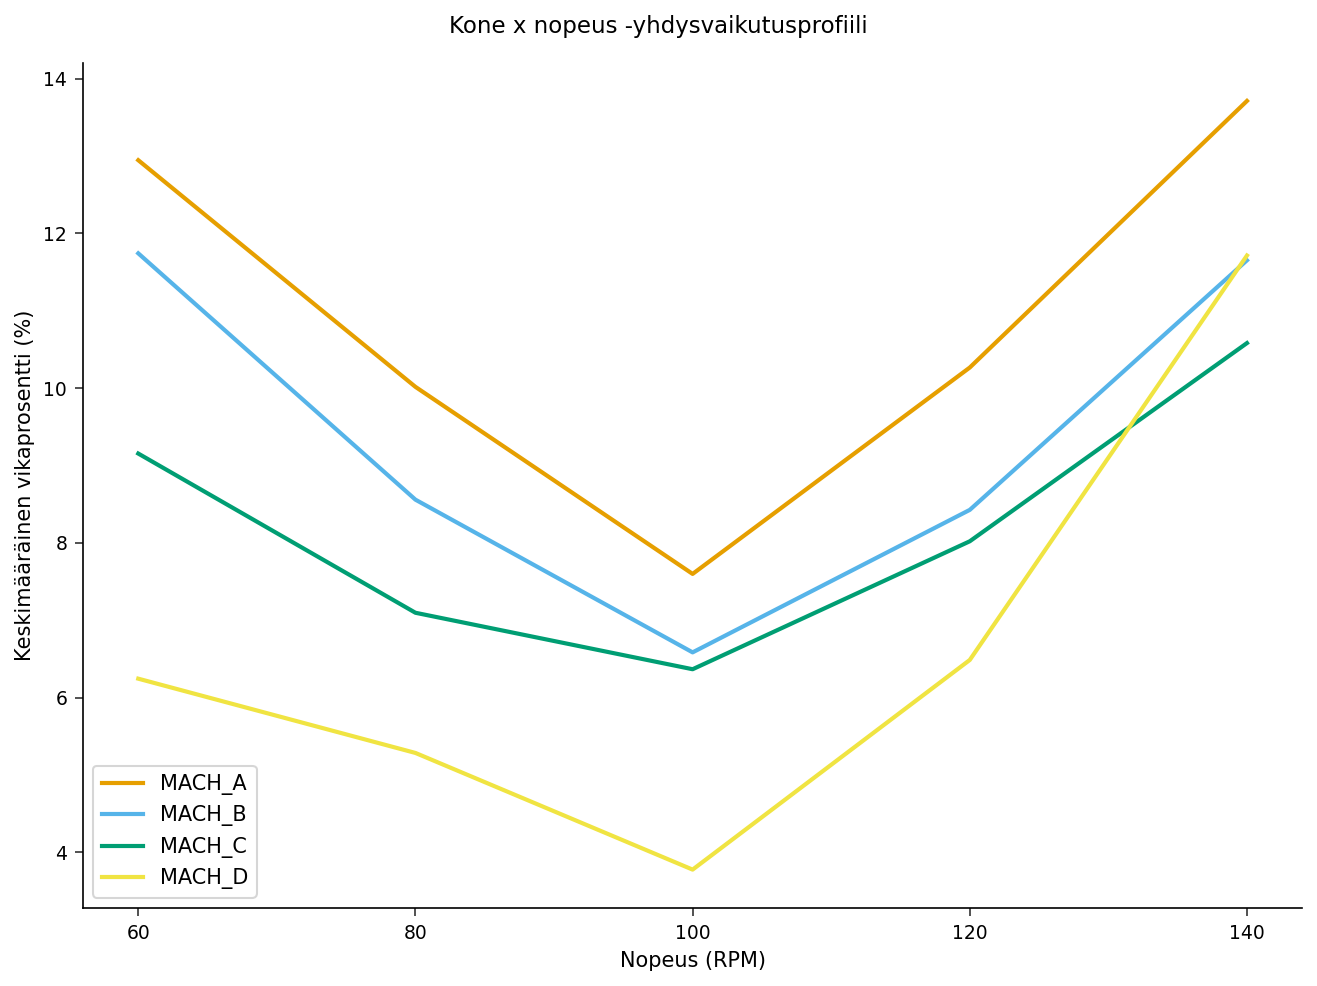

In [3]:
/* --------------------------------------------------------
   Yhdysvaikutuskuvio: keskimääräinen vikaprosentti nopeuden ja koneen mukaan
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.molding_experiment NOPRINT;
    LUOKKA machine speed;
    MUUTTUJA defect_rate;
    TULOSTE out=work.cell_means mean=mean_defect;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=work.cell_means(MISSÄ=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS NIMIKE='Nopeus (RPM)' VALUES=(60 80 100 120 140);
    YAXIS NIMIKE='Keskimääräinen vikaprosentti (%)';
    OTSIKKO 'Kone x nopeus -yhdysvaikutusprofiili';
SUORITA;

---

                                 Vikaprosentti ja vetolujuus koneen ja nopeuden mukaan                                  

            The Mixed Procedure             
             Model Information              

Item                                   Value
-------------------------  -----------------
Dependent Variable         Vikaprosentti (%)
Estimation Method                       REML
Degrees of Freedom Method      Kenward-Roger
Number of Observations                   100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

          Type III Tests of Fixed Effects           

Effect          Num DF    Den DF   F Value    Pr > F
------------  --------  --------  --------  --------
Nopeusasetus         4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC (Smaller


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


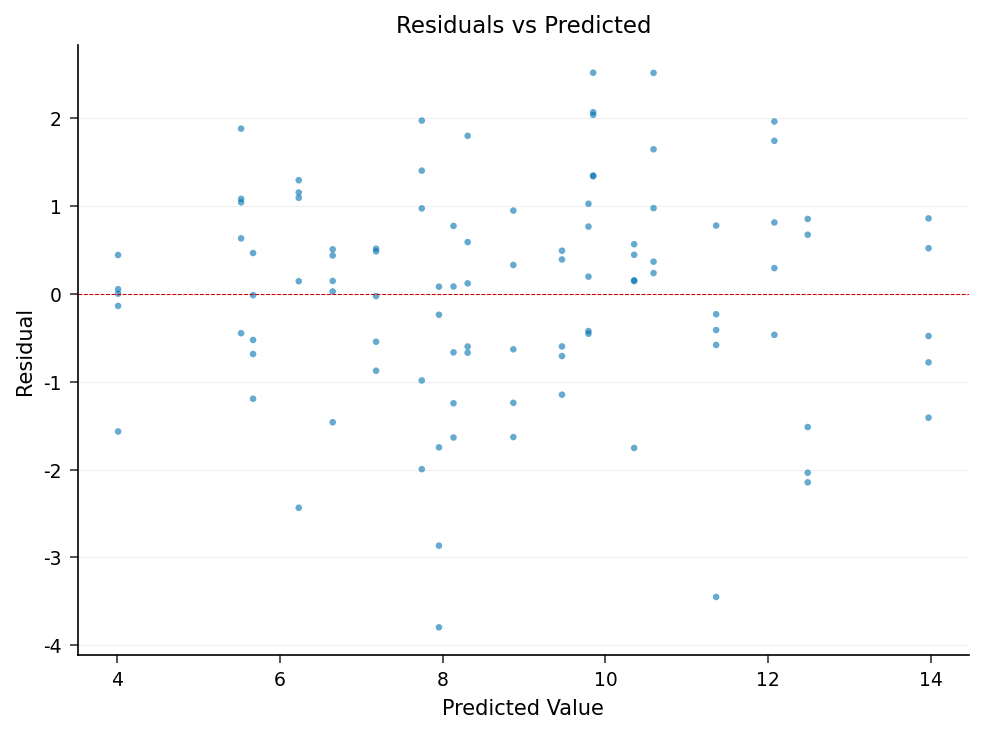

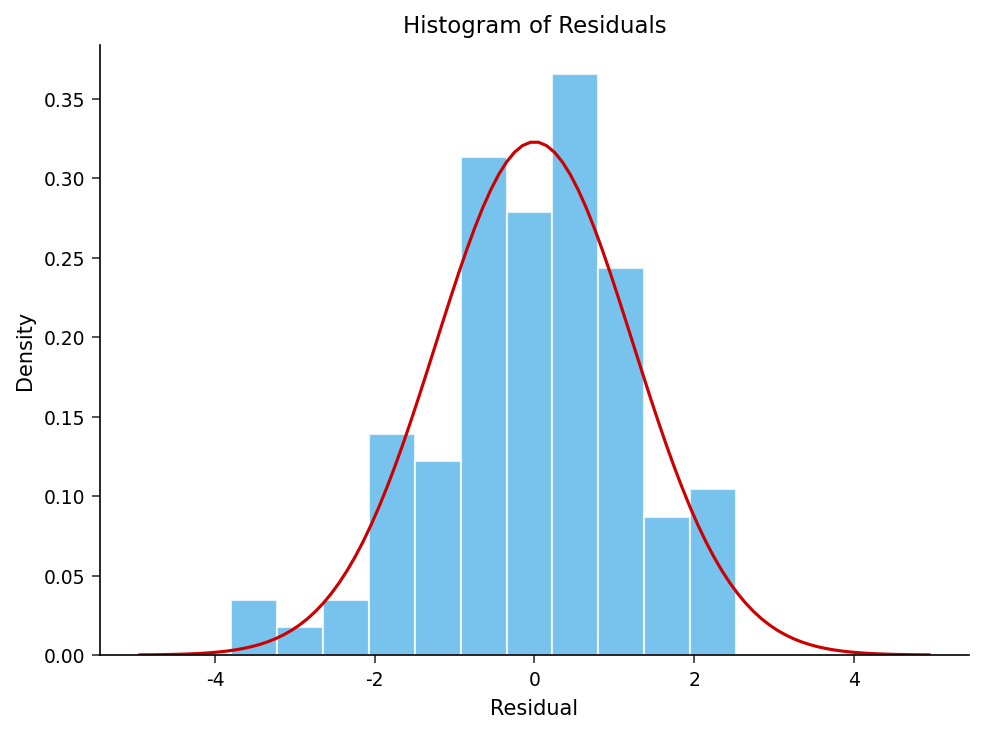

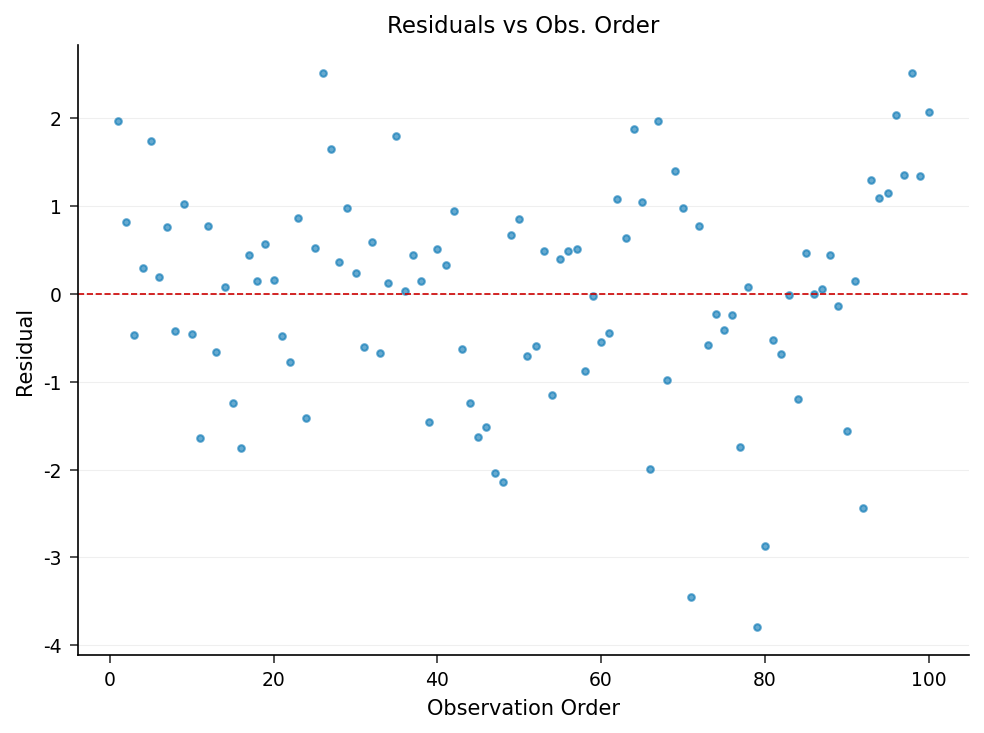

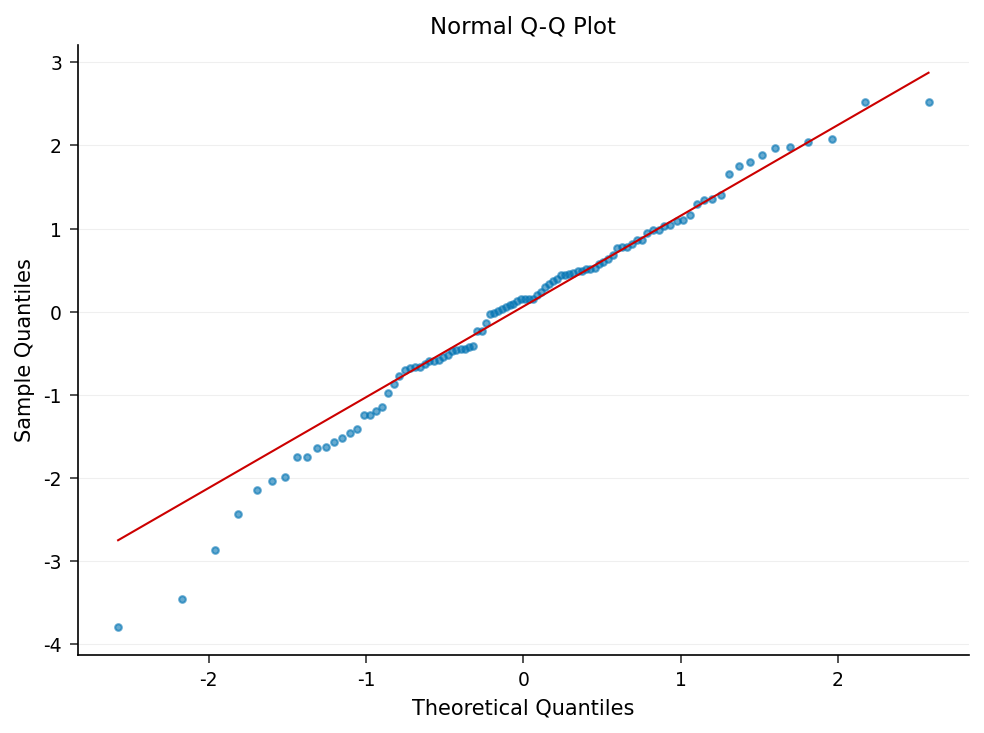

In [4]:
/* --------------------------------------------------------
   Osaruutukokeen sekamallianalyysi
   Kone on satunnainen (pääruudun virhe)
   Nopeus on kiinteä (osaruututekijä)
   -------------------------------------------------------- */
PROSEDUURI MIXED TIEDOT=work.molding_experiment METHOD=reml;
    LUOKKA machine speed_label;
    MODEL defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    NIMIKE machine='Kone' speed_label='Nopeusasetus' defect_rate='Vikaprosentti (%)';
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    OTSIKKO 'Osaruutuanalyysi: nopeuden vaikutus vikaprosenttiin';
SUORITA;

In [5]:
/* --------------------------------------------------------
   Tunnistetaan optimaalinen nopeusasetus
   -------------------------------------------------------- */
PROSEDUURI LAJITTELE TIEDOT=work.speed_lsmeans;
    MUKAAN ESTIMATE;
SUORITA;

TIEDOT work.optimal_speed;
    ASETA work.speed_lsmeans(obs=1);
    SÄILYTÄ speed_label ESTIMATE stderr LOWER UPPER;
    NIMIKE speed_label = 'Optimaalinen nopeus'
          ESTIMATE = 'PNS-keskiarvo vikaprosentti'
          LOWER = '95 %:n LV alaraja'
          UPPER = '95 %:n LV yläraja';
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.optimal_speed noobs NIMIKE;
    OTSIKKO 'Suositeltu käyttönopeus pienimmälle vikaprosentille';
SUORITA;

                                  Suositeltu käyttönopeus pienimmälle vikaprosentille                                   

Optimaalinen nopeus  PNS-keskiarvo vikaprosentti  StdErr  95 %:n LV alaraja   95 %:n LV yläraja
                  .                        6.081  0.9266             3.3645              8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Varianssikomponenttien hajotelma
   -------------------------------------------------------- */
PROSEDUURI TULOSTA TIEDOT=work.split_covparms noobs;
    OTSIKKO 'Varianssikomponentit: kone vs. jäännös';
SUORITA;

                                         Varianssikomponentit: kone vs. jäännös                                         

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Tulkinta

Osaruutumalli jakaa vikaprosentin vaihtelun kahteen kerrokseen.
**Koneen (pääruudun) varianssikomponentti on 3.10** ja **jäännöksen
(osaruudun) varianssi on 1.66**, joten koneiden väliset erot
selittävät noin **65 %** kokonaisvarianssista (3.10 / (3.10 + 1.66)).
Tämä suuri koneiden välinen osuus vahvistaa, että kone on todellinen
prosessivaihtelun lähde ja että osaruutuasetelma - eikä täysin
satunnaistettu analyysi - on oikea viitekehys.

Kiinteän nopeusvaikutuksen tyypin III testi on erittäin merkitsevä:
**F(4, 92) = 60.26, p < .0001**, joten RPM-asetus vaikuttaa
voimakkaasti vikaprosenttiin. PNS-keskiarvot piirtävät selkeän
kvadraattisen vasteen, jonka minimi on keskimmäisellä nopeudella:

| Nopeus | PNS-keskiarvo vikaprosentti (%) | 95 %:n LV |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

Tukey-korjatut parivertailut osoittavat, että **100 RPM on
merkitsevästi alempi kuin jokainen muu asetus** (korjattu p <= 0.0009
verrattuna 80, 120, 60 ja 140 RPM:iin). 80 RPM ja 120 RPM sijoittuvat
keskivaiheille eivätkä eroa toisistaan (erotus 0.56, korjattu
p = 0.6430), kun taas 60 RPM ja 140 RPM tuottavat korkeimmat
vikaprosentit.

**Tuotantosuositus:** vakioidaan tuotanto **100 RPM:ään** kaikilla
neljällä koneella, jolloin malli estimoi pienimmän vikaprosentin
(6.08 %). Koska koneen varianssikomponentti (3.10) on vaihtelun
hallitseva lähde, jatkotyössä kannattaa kohdentaa konekohtaista
kalibrointia - yhdysvaikutusprofiili näyttää, että MACH_D toimii
johdonmukaisesti alimmalla ja MACH_A korkeimmalla tasolla - jotta
koneiden välinen ero saadaan kavennettua valitussa 100 RPM
-asetuspisteessä.

---

In [7]:
/* --------------------------------------------------------
   Viedään nopeusoptimointituloksia insinööreille
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu teknologialla <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>